# Download the datasets from the Wolrd bank

In [ ]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

In [46]:
s = requests.Session()
s.mount("https://", HTTPAdapter(max_retries=Retry(total=5, backoff_factor=2, status_forcelist=[429, 500, 502, 503, 504], allowed_methods=["GET"])))

country = "USA"
codes = [
    "SL.UEM.NEET.FE.ZS", "SL.UEM.NEET.MA.ZS", "SL.UEM.NEET.ZS",
    "SE.PRM.UNER.ZS", "SE.PRM.UNER.FE.ZS", "SE.PRM.UNER.MA.ZS", "SE.PRM.UNER", "SE.PRM.UNER.FE", "SE.PRM.UNER.MA",
    "SL.UEM.1524.FE.NE.ZS", "SL.UEM.1524.MA.NE.ZS", "SL.UEM.1524.NE.ZS",
    "SE.PRM.CMPT.FE.ZS", "SE.PRM.CMPT.MA.ZS", "SE.PRM.CMPT.ZS",
    "SE.SEC.UNER.LO.ZS", "SE.SEC.CUAT.LO.ZS", "SE.SEC.CMPT.LO.ZS",
    "SE.SEC.ENRR", "SE.SEC.ENRR.FE", "SE.SEC.ENRR.MA", "SE.SEC.UNER.LO.FE.ZS", "SE.SEC.UNER.LO.MA.ZS",
    "SE.SEC.TCAQ.LO.ZS", "SE.SEC.TCAQ.LO.FE.ZS", "SE.SEC.TCAQ.LO.MA.ZS",
    "SE.SEC.TCAQ.ZS", "SE.SEC.TCAQ.FE.ZS", "SE.SEC.TCAQ.MA.ZS",
    "SE.PRM.TCAQ.MA.ZS", "SE.PRM.TCAQ.FE.ZS", "SE.PRM.TCAQ.ZS",
    "SE.SEC.TCAQ.UP.ZS", "SE.SEC.TCAQ.UP.FE.ZS", "SE.SEC.TCAQ.UP.MA.ZS",
    "SE.SEC.ENRL.LO.TC.ZS", "SE.PRE.ENRL.TC.ZS", "SE.PRM.ENRL.TC.ZS", "SE.SEC.ENRL.TC.ZS", "SE.TER.ENRL.TC.ZS", "SE.SEC.ENRL.UP.TC.ZS",
    "SE.XPD.TOTL.GD.ZS", "SE.XPD.TOTL.GB.ZS",
]
params = {"format": "json", "date": "2016:2025", "per_page": 1000}

rows, failed = [], []
for code in codes:
    url = f"https://api.worldbank.org/v2/country/{country}/indicator/{code}"
    try:
        res = s.get(url, params=params, timeout=(10, 120)).json()
        rows += res[1] or [] if len(res) > 1 else []
    except Exception as e:
        failed.append((code, str(e)))

df_long = pd.json_normalize(rows)[["country.value", "countryiso3code", "indicator.value", "indicator.id", "date", "value"]]
df_long.columns = ["Country Name", "Country Code", "Series Name", "Series Code", "year", "value"]
df_wide = df_long.pivot_table(index=["Country Name", "Country Code", "Series Name", "Series Code"], columns="year", values="value", aggfunc="first").reset_index()

In [47]:
df_wide.to_csv("../data/WD_USA_NEET.csv", index=False)
df_wide = pd.read_csv("../data/WD_USA_NEET.csv")

# 1. NEET & youth unemployment

=== NEET: change 2022 -> 2025 (pp) ===
 NEET, total     0.35
NEET, female    0.12
NEET, male      0.58
dtype: float64 

=== Youth unemp.: change 2022 -> 2025 (pp) ===
 Youth unemp., total     1.85
Youth unemp., female    1.54
Youth unemp., male      2.15
dtype: float64 



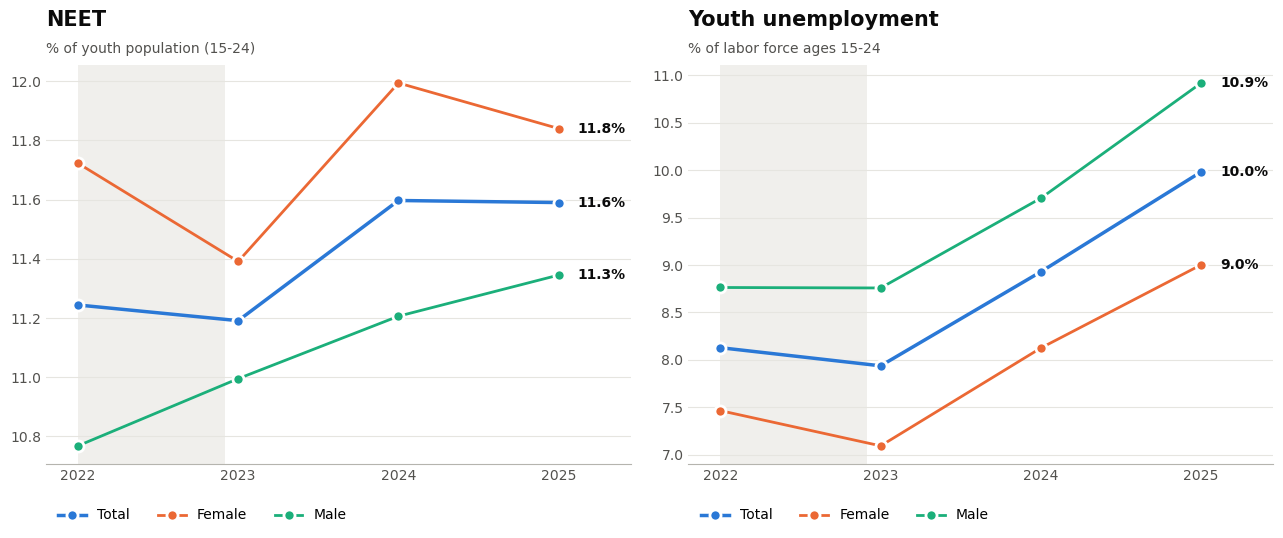

In [48]:
labor = {"NEET, total": "SL.UEM.NEET.ZS", "NEET, female": "SL.UEM.NEET.FE.ZS", "NEET, male": "SL.UEM.NEET.MA.ZS",
         "Youth unemp., total": "SL.UEM.1524.NE.ZS", "Youth unemp., female": "SL.UEM.1524.FE.NE.ZS", "Youth unemp., male": "SL.UEM.1524.MA.NE.ZS"}
indicators = df_wide.set_index("Series Code").filter(regex=r"^\d{4}$").rename(columns=int)
labor_w = pd.DataFrame({k: indicators.loc[v] for k, v in labor.items()})

colors = {"total": "#2a78d6", "female": "#eb6834", "male": "#1baf7a"}
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, prefix, title, subtitle in zip(axes, ["NEET", "Youth unemp."], ["NEET", "Youth unemployment"],
                                       ["% of youth population (15-24)", "% of labor force ages 15-24"]):
    sub = labor_w.filter(like=prefix).loc[2022:]
    ax.axvspan(2022, 2022 + 11 / 12, color="#e6e5e0", alpha=0.6, lw=0)
    for col in sub:
        g = col.split(", ")[1]
        ax.plot(sub.index, sub[col], color=colors[g], lw=2.5 if g == "total" else 2, marker="o", ms=8,
                mec="white", mew=2, label=g.capitalize(), zorder=3)
        ax.text(2025.12, sub[col].iloc[-1], f"{sub[col].iloc[-1]:.1f}%", va="center", fontsize=10,
                fontweight="bold", color="#0b0b0b")
    ax.set_title(title, loc="left", fontsize=15, fontweight="bold", color="#0b0b0b", pad=28)
    ax.text(0, 1.03, subtitle, transform=ax.transAxes, fontsize=10, color="#52514e")
    ax.set_xticks(range(2022, 2026))
    ax.set_xlim(2021.8, 2025.45)
    ax.legend(loc="upper left", bbox_to_anchor=(0, -0.08), ncol=3, frameon=False, fontsize=10)
    ax.yaxis.grid(True, color="#e6e5e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0, colors="#52514e")
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#b5b4ae")
    print(f"=== {prefix}: change 2022 -> 2025 (pp) ===\n", (sub.loc[2025] - sub.loc[2022]).round(2), "\n")
plt.tight_layout()
plt.savefig("fig1_labor_trend.png", dpi=200)
plt.savefig("../frontend/public/charts/wb_neet_unemployment.png", dpi=200, bbox_inches="tight")  # used on the website

- NEET (%): The share of the total youth population that is not in education, employment, or training. For example, 11.6% means that about 11.6 out of every 100 young people are NEET.
- Youth unemployment rate (%): The denominator is the labor force aged 15–24, meaning young people who are either working or actively looking for work. The rate is the share of that labor force who are looking for work but do not have a job. Young people who are not looking for work, such as students, are not in the denominator. For example, 9.98% means that about 10 out of every 100 young people in the labor force are unemployed.

# 2. Break down the NEET populations

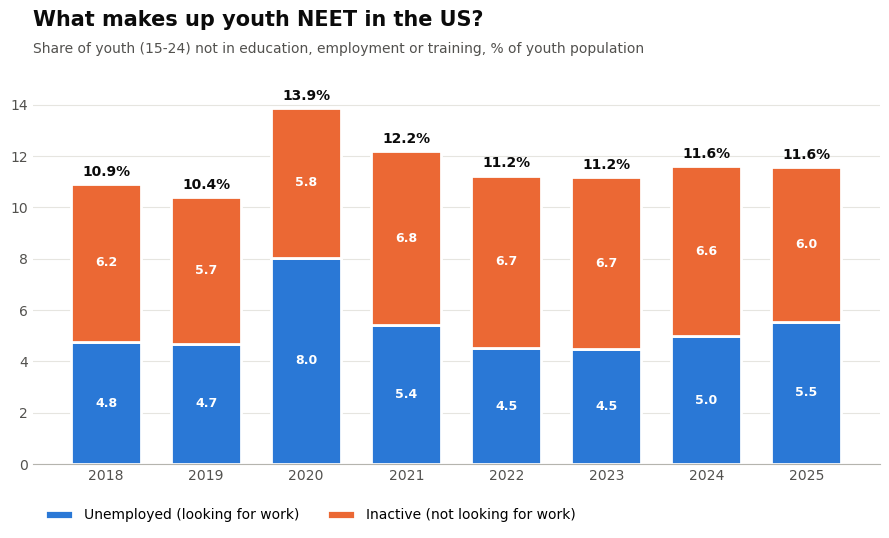

In [69]:
import requests

# NEET decomposition (total): unemployed (unemp. rate x LFPR) vs inactive (residual), % of youth population
lfpr = pd.Series({int(x["date"]): x["value"] for x in requests.get(
    "https://api.worldbank.org/v2/country/USA/indicator/SL.TLF.ACTI.1524.NE.ZS",
    params={"format": "json", "date": "2016:2025"}, timeout=60).json()[1]}).sort_index()
neet_total = labor_w["NEET, total"].loc[2018:]
unemployed = (labor_w["Youth unemp., total"] * lfpr / 100).loc[2018:]
inactive = neet_total - unemployed

fig, ax = plt.subplots(figsize=(9, 5.5))
years = unemployed.index.astype(str)
for bottom, vals, color, name in [(0, unemployed, "#2a78d6", "Unemployed (looking for work)"),
                                  (unemployed, inactive, "#eb6834", "Inactive (not looking for work)")]:
    bars = ax.bar(years, vals, bottom=bottom, width=0.7, color=color, edgecolor="white", linewidth=2, label=name)
    ax.bar_label(bars, fmt="%.1f", label_type="center", color="white", fontsize=9, fontweight="bold")
for x, total in zip(years, neet_total):
    ax.text(x, total + 0.2, f"{total:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold", color="#0b0b0b")

ax.set_title("What makes up youth NEET in the US?", loc="left", fontsize=15, fontweight="bold", color="#0b0b0b", pad=28)
ax.text(0, 1.03, "Share of youth (15-24) not in education, employment or training, % of youth population",
        transform=ax.transAxes, fontsize=10, color="#52514e")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.08), ncol=2, frameon=False, fontsize=10)
ax.set_ylim(0, neet_total.max() * 1.12)
ax.yaxis.grid(True, color="#e6e5e0", lw=0.8)
ax.set_axisbelow(True)
ax.tick_params(length=0, colors="#52514e")
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#b5b4ae")
plt.tight_layout()
plt.savefig("fig_neet_decomposition.png", dpi=200)
plt.savefig("../frontend/public/charts/wb_neet_breakdown.png", dpi=200, bbox_inches="tight")  # used on the website

- Unemployment: youth unemployment rate × labor force participation rate. This is the share of the youth population that is unemployed.
- Inactivity: NEET − unemployment. This is the portion of NEET who are not even looking for work.

1. The 2020 spike was due to unemployment. Unemployment rose from 4.69% to 8.04%, while inactivity remained nearly unchanged.
2. The reason NEET was higher in 2021–2023 than in 2019 was inactivity. Unemployment returned below its 2019 level, but inactivity stayed elevated, rising from 5.7% to 6.7%. This means more young people were not even looking for work.
3. The 2023–2025 increase was again due to unemployment. Unemployment rose from 4.47% to 5.55%.

# 3. Youth-to-overall unemployment ratio

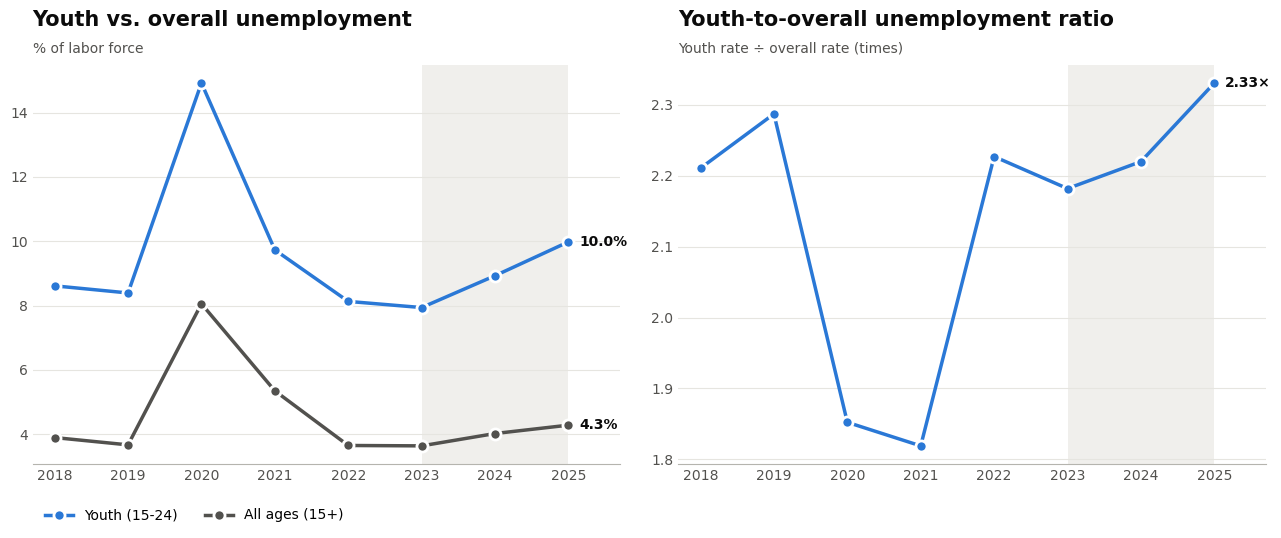

In [71]:
# Youth-to-overall unemployment ratio: > 1 means youth face higher unemployment than the labor force as a whole
total_unemp = pd.Series({int(x["date"]): x["value"] for x in requests.get(
    "https://api.worldbank.org/v2/country/USA/indicator/SL.UEM.TOTL.NE.ZS",
    params={"format": "json", "date": "2016:2025"}, timeout=60).json()[1]}).sort_index()
rates = pd.DataFrame({"Youth (15-24)": labor_w["Youth unemp., total"], "All ages (15+)": total_unemp}).loc[2018:]
ratio = rates["Youth (15-24)"] / rates["All ages (15+)"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
panels = [(axes[0], rates, {"Youth (15-24)": "#2a78d6", "All ages (15+)": "#52514e"}, "Youth vs. overall unemployment",
           "% of labor force", "{:.1f}%"),
          (axes[1], ratio.to_frame("Youth ÷ all ages"), {"Youth ÷ all ages": "#2a78d6"}, "Youth-to-overall unemployment ratio",
           "Youth rate ÷ overall rate (times)", "{:.2f}×")]
for ax, data, colors, title, subtitle, fmt in panels:
    ax.axvspan(2018, 2022 + 11 / 12, color="#e6e5e0", alpha=0.6, lw=0)  # pre-AI: before ChatGPT (Nov 2022)
    for col, c in colors.items():
        ax.plot(data.index, data[col], color=c, lw=2.5, marker="o", ms=8, mec="white", mew=2, label=col, zorder=3)
        ax.text(2025.15, data[col].iloc[-1], fmt.format(data[col].iloc[-1]), va="center", fontsize=10,
                fontweight="bold", color="#0b0b0b")
    ax.set_title(title, loc="left", fontsize=15, fontweight="bold", color="#0b0b0b", pad=28)
    ax.text(0, 1.03, subtitle, transform=ax.transAxes, fontsize=10, color="#52514e")
    ax.set_xticks(range(2018, 2026))
    ax.set_xlim(2017.7, 2025.7)
    ax.yaxis.grid(True, color="#e6e5e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0, colors="#52514e")
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#b5b4ae")
axes[0].legend(loc="upper left", bbox_to_anchor=(0, -0.08), ncol=2, frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig("fig_youth_unemp_ratio.png", dpi=200)
plt.savefig("../frontend/public/charts/wb_youth_unemp_ratio.png", dpi=200, bbox_inches="tight")  # used on the website

* From 2023 (2023~2025) onward (the gray band), both lines rise, but at different slopes.
   * Youth: 7.9% → 10.0% (+2.0pp)
   * Overall: 3.6% → 4.3% (+0.6pp)

While the general economic conditions did deteriorate somewhat, the youth unemployment rate rose roughly three times as steeply.

The rise in youth unemployment since 2023 cannot be explained by cyclical slowdown alone. The overall unemployment rate rose only slightly, while youth unemployment rose much more sharply, widening the youth–overall gap to its largest point in the past decade. This suggests that young people have been growing relatively more disadvantaged in the labor market.

# 4. Comparison with G7 countries

In [22]:
g7 = {"USA": "United States", "GBR": "United Kingdom", "DEU": "Germany", "FRA": "France",
      "ITA": "Italy", "JPN": "Japan", "CAN": "Canada"}

def fetch_g7(code):
    rows = requests.get(f"https://api.worldbank.org/v2/country/{';'.join(g7)}/indicator/{code}",
                        params={"format": "json", "date": "2016:2025", "per_page": 1000}, timeout=120).json()[1]
    return pd.DataFrame([(x["countryiso3code"], int(x["date"]), x["value"]) for x in rows],
                        columns=["country", "year", "value"]).pivot(index="year", columns="country", values="value")

neet_g7 = fetch_g7("SL.UEM.NEET.ZS")
unemp_g7 = fetch_g7("SL.UEM.1524.NE.ZS")

def style(ax, title, subtitle, grid_axis):
    ax.set_title(title, loc="left", fontsize=14, fontweight="bold", color="#0b0b0b", pad=28)
    ax.text(0, 1.03, subtitle, transform=ax.transAxes, fontsize=10, color="#52514e")
    getattr(ax, f"{grid_axis}axis").grid(True, color="#e6e5e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0, colors="#52514e")
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#b5b4ae")

highlight = lambda idx: ["#2a78d6" if c == "United States" else "#c3c2b7" for c in idx]

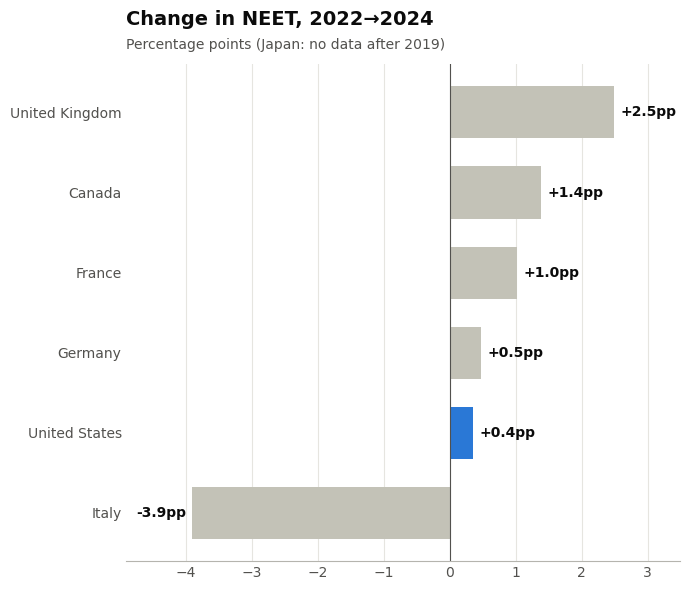

In [36]:
# Change in NEET, 2022 -> 2024 (latest year with data for most G7)
neet_chg = (neet_g7.loc[2024] - neet_g7.loc[2022]).dropna().rename(g7).sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(neet_chg.index, neet_chg, color=highlight(neet_chg.index), height=0.65)
ax.axvline(0, color="#52514e", lw=0.8)
for y, v in enumerate(neet_chg):
    ax.text(v + (0.1 if v >= 0 else -0.1), y, f"{v:+.1f}pp", va="center", ha="left" if v >= 0 else "right",
            fontsize=10, fontweight="bold", color="#0b0b0b")
style(ax, "Change in NEET, 2022→2024", "Percentage points (Japan: no data after 2019)", "x")
ax.set_xlim(neet_chg.min() - 1, neet_chg.max() + 1)
plt.tight_layout()
plt.savefig("fig_g7_neet_change.png", dpi=200)

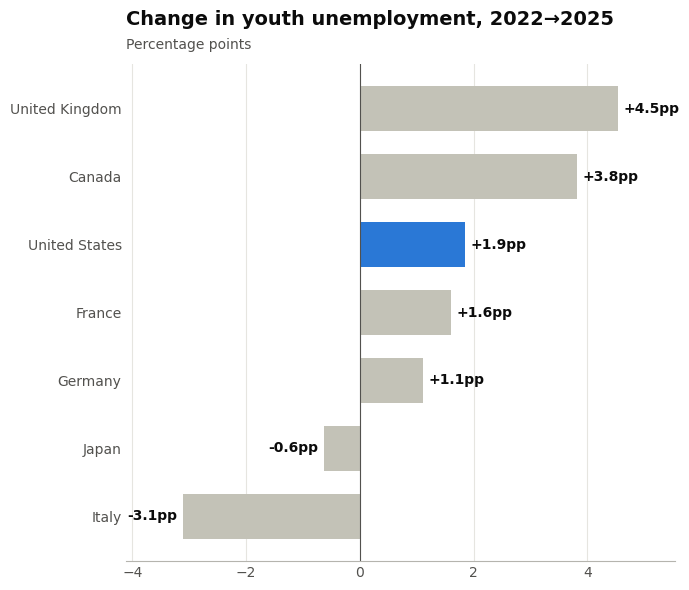

In [28]:
# Change in youth unemployment, 2022 -> 2025
unemp_chg = (unemp_g7.loc[2025] - unemp_g7.loc[2022]).rename(g7).sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(unemp_chg.index, unemp_chg, color=highlight(unemp_chg.index), height=0.65)
ax.axvline(0, color="#52514e", lw=0.8)
for y, v in enumerate(unemp_chg):
    ax.text(v + (0.1 if v >= 0 else -0.1), y, f"{v:+.1f}pp", va="center", ha="left" if v >= 0 else "right",
            fontsize=10, fontweight="bold", color="#0b0b0b")
style(ax, "Change in youth unemployment, 2022→2025", "Percentage points", "x")
ax.set_xlim(unemp_chg.min() - 1, unemp_chg.max() + 1)
plt.tight_layout()
plt.savefig("fig_g7_unemp_change.png", dpi=200)

In [45]:
# NEET vs youth unemployment, 2024 cross-section: one observation per OECD country (interactive)
import plotly.graph_objects as go
from scipy.stats import pearsonr

oecd = ["AUS", "AUT", "BEL", "CAN", "CHE", "CHL", "COL", "CRI", "CZE", "DEU", "DNK", "ESP", "EST", "FIN", "FRA",
        "GBR", "GRC", "HUN", "IRL", "ISL", "ISR", "ITA", "JPN", "KOR", "LTU", "LUX", "LVA", "MEX", "NLD", "NOR",
        "NZL", "POL", "PRT", "SVK", "SVN", "SWE", "TUR", "USA"]

def fetch_2024(code):
    rows = requests.get(f"https://api.worldbank.org/v2/country/{';'.join(oecd)}/indicator/{code}",
                        params={"format": "json", "date": "2024", "per_page": 1000}, timeout=120).json()[1]
    return pd.DataFrame([(x["countryiso3code"], x["country"]["value"], x["value"]) for x in rows],
                        columns=["code", "name", "value"]).set_index("code")

neet_24, unemp_24 = fetch_2024("SL.UEM.NEET.ZS"), fetch_2024("SL.UEM.1524.NE.ZS")
cross = pd.DataFrame({"name": neet_24["name"], "NEET": neet_24["value"], "unemp": unemp_24["value"]}).dropna().sort_values("name")
res = pearsonr(cross["NEET"], cross["unemp"])
print(f"r = {res.statistic:.2f}, p = {res.pvalue:.3f}, n = {len(cross)}")

us, others = cross.loc["USA"], cross.drop("USA")
hover = "<b>%{customdata}</b><br>Youth unemployment: %{x:.1f}%<br>NEET: %{y:.1f}%<extra></extra>"
fig = go.Figure([
    go.Scatter(x=others["unemp"], y=others["NEET"], customdata=others["name"], mode="markers", name="Other OECD",
               marker=dict(size=11, color="#c3c2b7", line=dict(color="white", width=1.5)), hovertemplate=hover),
    go.Scatter(x=[us["unemp"]], y=[us["NEET"]], customdata=[us["name"]], text=["United States"], mode="markers+text",
               textposition="top right", textfont=dict(color="#2a78d6", size=12), name="United States",
               marker=dict(size=14, color="#2a78d6", line=dict(color="white", width=2)), hovertemplate=hover),
    go.Scatter(x=[], y=[], customdata=[], text=[], mode="markers+text", textposition="top right",
               textfont=dict(color="#e34948", size=12), name="Selected",
               marker=dict(size=14, color="#e34948", line=dict(color="white", width=2)), hovertemplate=hover),
])
# Dropdown: the chosen country is drawn as the red "Selected" trace
buttons = [dict(label="Compare with…", method="restyle", args=[{"x": [[]], "y": [[]], "customdata": [[]], "text": [[]]}, [2]])]
buttons += [dict(label=row["name"], method="restyle",
                 args=[{"x": [[row["unemp"]]], "y": [[row["NEET"]]], "customdata": [[row["name"]]], "text": [[row["name"]]]}, [2]])
            for _, row in others.iterrows()]
fig.update_layout(
    title=dict(text=f"<b>NEET vs. youth unemployment, 2024</b><br><span style='font-size:13px;color:#52514e'>"
                    f"OECD countries, one point per country2 (n = {len(cross)})</span>",
               x=0.02, xanchor="left", font=dict(size=18, color="#0b0b0b")),
    updatemenus=[dict(buttons=buttons, x=1, xanchor="right", y=1.12, yanchor="bottom", bgcolor="white",
                      bordercolor="#b5b4ae")],
    xaxis=dict(title="Youth unemployment (% of labor force 15-24)", gridcolor="#e6e5e0", zeroline=False),
    yaxis=dict(title="NEET (% of youth)", gridcolor="#e6e5e0", zeroline=False),
    plot_bgcolor="white", paper_bgcolor="white", font=dict(color="#52514e"), showlegend=False,
    width=850, height=600, margin=dict(t=110),
)
fig.write_html("fig_oecd_neet_vs_unemp_2024.html")
# website copy (used on the website): resizes to the screen, loads plotly.js from its CDN, and is
# phone-friendly: no drag/scroll zoom (a finger drag scrolls the page), no toolbar, no built-in title
# (the page has one). Plotly's dropdown is replaced by a native <select> (the phone's own picker), and
# tapping a point selects that country too.
import json
web = go.Figure(fig).update_layout(width=None, height=None, autosize=True, title=None, dragmode=False,
                                   margin=dict(l=55, r=15, t=15, b=55))
web.layout.updatemenus = ()  # drop Plotly's own dropdown (replaced by the <select> below)
web.update_xaxes(fixedrange=True, title="Youth unemployment (% of labor force)")  # shorter, fits phones
web.update_yaxes(fixedrange=True)
picker = json.dumps(others.sort_values("name")[["name", "unemp", "NEET"]].values.tolist())
post_script = """
var gd = document.getElementById('{plot_id}');
var data = PICKER;
var sel = document.createElement('select');
sel.style.cssText = 'display:block;font:16px system-ui,sans-serif;padding:8px;margin:0 0 6px;max-width:100%;';
sel.innerHTML = '<option value="">Compare with a country…</option>' +
  data.map(function (d, i) { return '<option value="' + i + '">' + d[0] + '</option>'; }).join('');
gd.parentNode.insertBefore(sel, gd);
function pick(i) {
  if (i === '') { Plotly.restyle(gd, {x: [[]], y: [[]], customdata: [[]], text: [[]]}, [2]); return; }
  var d = data[i];
  Plotly.restyle(gd, {x: [[d[1]]], y: [[d[2]]], customdata: [[d[0]]], text: [[d[0]]]}, [2]);
}
sel.addEventListener('change', function () { pick(sel.value); });
gd.on('plotly_click', function (ev) {
  var i = data.findIndex(function (d) { return d[0] === ev.points[0].customdata; });
  if (i >= 0) { sel.value = String(i); pick(String(i)); }
});
""".replace("PICKER", picker)
web.write_html("../frontend/public/charts/wb_oecd_scatter.html", include_plotlyjs="cdn",
               default_width="100%", default_height="480px", post_script=post_script,
               config={"responsive": True, "displayModeBar": False, "scrollZoom": False})
fig.show()

r = 0.16, p = 0.349, n = 36
